# Xarxes neuronals en Pytorch

Qualsevol entrenament d'un model en Pytorch implica els quatre pasos en bucle: Prediccions, Càlcul de la pèrdua, `Backward` i `step`.

El codi a continuació importa les llibreries i crea les dades com hem vist altres vegades

In [7]:
import numpy as np
from sklearn.linear_model import LinearRegression
import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import Dataset, TensorDataset, DataLoader
from torch.utils.data.dataset import random_split
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.style.use('fivethirtyeight')
device = 'cuda' if torch.cuda.is_available() else 'cpu'

<Axes: >

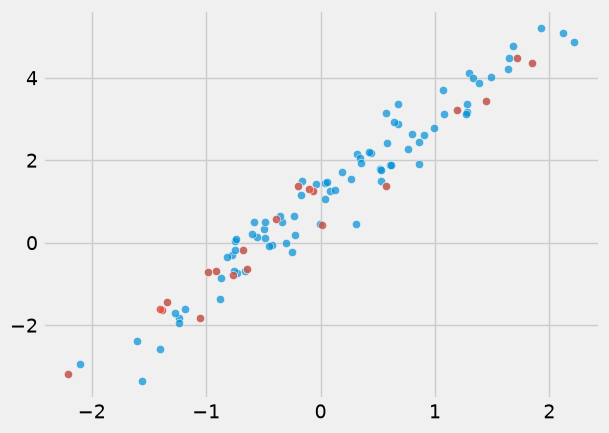

In [35]:
true_b = 1
true_w = 2
N = 100

# Data Generation
torch.manual_seed(42)
#Equivalent a np.random.seed(42)

x = torch.randn(N, dtype=torch.float)
epsilon = (.5 * torch.randn(N, dtype=torch.float))
y = true_b + true_w * x + epsilon

dataset = TensorDataset(x.unsqueeze(1), y.unsqueeze(1))
train_data, val_data = random_split(dataset, [80, 20])

# Extreure els tensors corresponents a train_data utilitzant els índexs del Subset
x_train_tensor = train_data.dataset.tensors[0][train_data.indices]
y_train_tensor = train_data.dataset.tensors[1][train_data.indices]

x_val_tensor = val_data.dataset.tensors[0][val_data.indices]
y_val_tensor = val_data.dataset.tensors[1][val_data.indices]

x_np = x.detach().cpu().numpy().flatten()
y_np = y.detach().cpu().numpy().flatten()

x_train_np = x_train_tensor.detach().cpu().numpy().flatten()
y_train_np = y_train_tensor.detach().cpu().numpy().flatten()

x_val_np = x_val_tensor.detach().cpu().numpy().flatten()
y_val_np = y_val_tensor.detach().cpu().numpy().flatten()


sns.scatterplot(x=x_np, y=y_np, alpha=0.7)
sns.scatterplot(x=x_val_np, y=y_val_np, alpha=0.7)

## Datasets i TensorDataset

L'entrenament en Pytorch sol ser molt costós computacionalment i complex. Mentre que al machine learning es crea la classe del model, es passen X,y i es fa fit(). El volum del problema a Deep Learning obliga a gestionar l'ingesta de dades d'una manera específica. Per tant, s'ha de seguir uns protocols i per a això existeix `Dataset` al conjunt d'utilitats de Pythorch.

Un dataset és com una llista de tuples que és iterable i indexable. 

Per fer el nostre propi Dataset hem d'heretar de `Dataset` i implementar les següents funcions:

In [26]:
class CustomDataset(Dataset):
    def __init__(self, x_tensor, y_tensor):
        self.x = x_tensor
        self.y = y_tensor
        
    def __getitem__(self, index):
        return (self.x[index], self.y[index])

    def __len__(self):
        return len(self.x)


train_data = CustomDataset(x_train_tensor, y_train_tensor)
print(train_data[0])

(tensor([-1.6047]), tensor([-2.3747]))


* `__init__` pren qualsevol argument que siga necessari per a construir una llista de tuples. En aquest cas són tensors, però pot ser un Dataframe, un arrat de Numpy o un CSV. No és precís carregat totes les dades a memòria. És possible que no tingam prou RAM. Per això, aquesta funció sols inicialitza la classe, però `__getitem__` ja gestionarà la càrrega a demanda.  
* `_-getitem__` Permet que siga indexable. Podem implementar la càrrega a demanda: https://docs.pytorch.org/tutorials/beginner/data_loading_tutorial.html#dataset-class
* `__len__` Ens dona la longitut del Dataset.

Per a un cas tant simple com aquest podem fer ús de `TensorDataset`, que implementa el mateix sense crear una classe. 

In [27]:
train_data = TensorDataset(x_train_tensor, y_train_tensor) # Alternativa a la classe
print(train_data[0])

(tensor([-1.6047]), tensor([-2.3747]))


## DataLoader

Fins ara els entrenaments els hem fer amb un únic `batch`. Com que eren problemes molt menuts no hi ha cap problema. Per poder fer el descens de gradient amb `mini-batches` deguem anar agafant troços del dataset. La classe `DataLoader` ens permetrà utilitzar un `Dataset` creat anteriorment per carregar el mini-batch desitjat i desordenar-lo aleatoriament si volem (sempre en entrenament menys en series temporals). 

El carregador es comportarà com un iterador i ens anirà carregant els batches. 

És comú utilitzar batches de mida potència de 2 com 16,32,64,128... L'elecció de la mida depèn de problema i la memòria disponible. Amb batches menuts el resultat pot ser més precís, generalitzat i pot trobar mínims millors al generar `soroll estocàstic` que escapa de mínims locals. Es penalitza perquè implica no utilitzar totalment la memòria de vídeo en cada execució. El batches grans s'aprofita la memòria millor i accelera l'entrenament. És un gradient més estable, però generalitzarà menys. Però es poden diluir dades interessants entre dades comuns. 

In [36]:
train_loader = DataLoader(
dataset=train_data,
batch_size=16,
shuffle=True,
)

In [37]:
next(iter(train_loader))

[tensor([[-0.4974],
         [-1.2742],
         [-0.3387],
         [ 0.5258],
         [ 0.6784],
         [ 0.0780],
         [ 0.6408],
         [-0.4502],
         [-0.8712],
         [ 0.3499],
         [ 0.0566],
         [-0.4879],
         [-0.2516],
         [-0.2316],
         [ 0.6105],
         [ 0.8008]]),
 tensor([[ 0.3326],
         [-1.7014],
         [ 0.5015],
         [ 1.5047],
         [ 2.8724],
         [ 1.2435],
         [ 2.9331],
         [-0.0781],
         [-0.8477],
         [ 1.9217],
         [ 1.4654],
         [ 0.1215],
         [-0.2199],
         [ 0.6455],
         [ 1.8776],
         [ 2.6382]])]

## La funció per fer un pas de l'entrenament

Per estalviar codi i tenir un procés d'entrenament més net es pot fer una funció que accepte el model, la funció de pèrdua i l'optimitzador i retorna una funció que fa un pas de l'entrenament. 

In [38]:
def make_train_step_fn(model, loss_fn, optimizer):
    # Builds function that performs a step in the train loop
    def perform_train_step_fn(x, y):
        # Sets model to TRAIN mode
        model.train()
        
        # Step 1 - Computes our model's predicted output - forward pass
        yhat = model(x)
        # Step 2 - Computes the loss
        loss = loss_fn(yhat, y)
        # Step 3 - Computes gradients for both "a" and "b" parameters
        loss.backward()
        # Step 4 - Updates parameters using gradients and the learning rate
        optimizer.step()
        optimizer.zero_grad()
        
        # Returns the loss
        return loss.item()
    
    # Returns the function that will be called inside the train loop
    return perform_train_step_fn

In [39]:
# Sets learning rate - this is "eta" ~ the "n" like Greek letter
lr = 0.1

torch.manual_seed(42)
# Now we can create a model and send it at once to the device
model = nn.Sequential(nn.Linear(1, 1)).to(device)

# Defines a SGD optimizer to update the parameters (now retrieved directly from the model)
optimizer = optim.SGD(model.parameters(), lr=lr)

# Defines a MSE loss function
loss_fn = nn.MSELoss(reduction='mean')

# Creates the train_step function for our model, loss function and optimizer
train_step_fn = make_train_step_fn(model, loss_fn, optimizer)

In [42]:
def mini_batch(device, data_loader, step_fn):
    mini_batch_losses = []
    for x_batch, y_batch in data_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        mini_batch_loss = step_fn(x_batch, y_batch)
        mini_batch_losses.append(mini_batch_loss)

    loss = np.mean(mini_batch_losses)
    return loss

# Defines number of epochs
n_epochs = 1000

losses = []

# For each epoch...
for epoch in range(n_epochs):
    # Computes average loss over all mini-batches - that's the epoch loss
    loss = mini_batch(device, train_loader, train_step_fn)
    
    losses.append(loss)

In [43]:
print(model.state_dict())

OrderedDict({'0.weight': tensor([[2.0408]]), '0.bias': tensor([1.0261])})


Analitzem el codi anterior. Es crida a `mini_batch` que crea un bucle per a cada época. Donat que es tracta de descens de gradient, cada època farà un `train_step_fn` per a cada batch. Ens interessa l'error de tota l'epoca, per tant, es calcula la mitjana de l'error. 

En l'exemple es faran en total (100/16)*1000 pasos d'entrenament, ja que recorre tots els `mini-batches` en cada `epoch`. 

El `state_dict` ens dona un resultat molt paregut al paràmetres reals. 

## Avaluació del model

Donat que tenim un conjunt de validació anem a calcular la pèrdua amb dades no vistes a l'entrenament. Utilitzarem el mètode `eval()` per posar el model en mode avaluació. Ara no canvia molt, però en el futur serà important quan apliquem `Dropout`.  

Ens fem una funció auxiliar per avaluar el model:

In [52]:
def make_val_step_fn(model, loss_fn):
    # Builds function that performs a step in the validation loop
    def perform_val_step_fn(x, y):
        # Sets model to EVAL mode
        model.eval()
        
        # Step 1 - Computes our model's predicted output - forward pass
        yhat = model(x)
        # Step 2 - Computes the loss
        loss = loss_fn(yhat, y)
        # There is no need to compute Steps 3 and 4, since we don't update parameters during evaluation
        return loss.item()
    
    return perform_val_step_fn

La nova versió del bucle d'entrenament inclurà l'avaluació del model. Aprofitarem la funció `mini_batch` però amb la diferència de que es farà dins d'un bloc `torch.no_grad()` per no fastidiar els gradients involuntàriament (encara que aquests steps en cocnret no fan el backward ni l'optimitzador):

In [53]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Sets learning rate - this is "eta" ~ the "n" like Greek letter
lr = 0.1

torch.manual_seed(42)
# Now we can create a model and send it at once to the device
model = nn.Sequential(nn.Linear(1, 1)).to(device)

# Defines a SGD optimizer to update the parameters (now retrieved directly from the model)
optimizer = optim.SGD(model.parameters(), lr=lr)

# Defines a MSE loss function
loss_fn = nn.MSELoss(reduction='mean')

# Creates the train_step function for our model, loss function and optimizer
train_step_fn = make_train_step_fn(model, loss_fn, optimizer)

# Creates the val_step function for our model and loss function
val_step_fn = make_val_step_fn(model, loss_fn)

val_loader = DataLoader(dataset=val_data, batch_size=16)

n_epochs = 200

losses = []
val_losses = []

for epoch in range(n_epochs):
    # inner loop
    loss = mini_batch(device, train_loader, train_step_fn)
    losses.append(loss)
    
    # VALIDATION
    # no gradients in validation!
    with torch.no_grad():
        val_loss = mini_batch(device, val_loader, val_step_fn)
        val_losses.append(val_loss)   

In [54]:
print(model.state_dict())

OrderedDict({'0.weight': tensor([[2.0591]]), '0.bias': tensor([1.0209])})


In [55]:
def plot_losses(losses, val_losses):
    fig = plt.figure(figsize=(10, 4))
    plt.plot(losses, label='Training Loss', c='b')
    plt.plot(val_losses, label='Validation Loss', c='r')
    plt.yscale('log')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    return fig

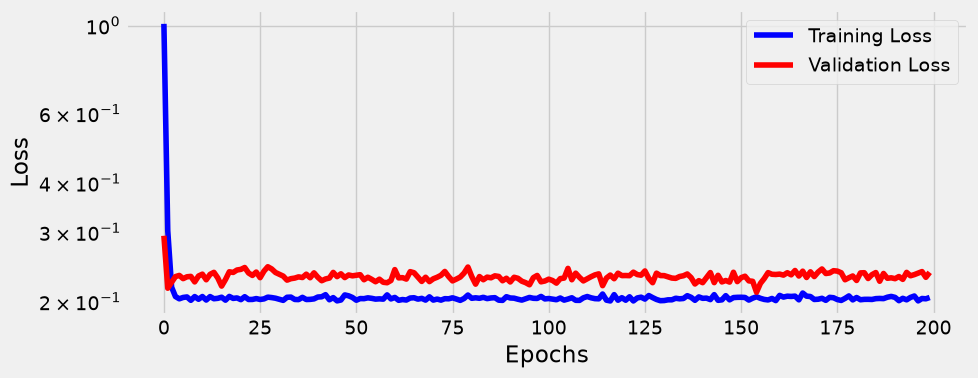

In [56]:
fig = plot_losses(losses, val_losses)

### TensorBoard

Els entrenaments poden durar moltes hores. Per monitorizar millor el seu funcionament tenim la ferramenta `TensorBoard` que forma part del projecte de la competència `Tensorflow`. 

Aquesta ferramenta genera una pàgina web que pot ser inserida en un Notebook o executada a banda. Tensorflow necessita un directori per als logs al que anomenarem `runs`.

In [67]:
# Carga la extensión de TensorBoard
%load_ext tensorboard
%tensorboard --logdir runs

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 29637), started 0:12:33 ago. (Use '!kill 29637' to kill it.)

In [61]:
writer = SummaryWriter('runs/test_linealRegression')

Mètodes que implementa el redactor de resums:

add_graph()
add_scalars()
add_scalar()
add_histogram()
add_images()
add_image()
add_figure()
add_video()
add_audio()
add_text()
add_embedding()
add_pr_curve()
add_custom_scalars()
add_mesh()
add_hparams()

Mètodes per escriure al disc:

flush()
close()

Crearem un gràfic bàsic per a aquest exemple de manera que es puga analitzar el que passa al directori `runs` i a Tensorflow desplegat

In [66]:
dummy_x, dummy_y = next(iter(train_loader))
writer.add_graph(model, dummy_x.to(device))

In [68]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Sets learning rate - this is "eta" ~ the "n" like Greek letter
lr = 0.1

torch.manual_seed(42)
# Now we can create a model and send it at once to the device
model = nn.Sequential(nn.Linear(1, 1)).to(device)

# Defines a SGD optimizer to update the parameters (now retrieved directly from the model)
optimizer = optim.SGD(model.parameters(), lr=lr)

# Defines a MSE loss function
loss_fn = nn.MSELoss(reduction='mean')

# Creates the train_step function for our model, loss function and optimizer
train_step_fn = make_train_step_fn(model, loss_fn, optimizer)

# Creates the val_step function for our model and loss function
val_step_fn = make_val_step_fn(model, loss_fn)

# Creates a Summary Writer to interface with TensorBoard
writer = SummaryWriter('runs/simple_linear_regression')

# Fetches a single mini-batch so we can use add_graph
x_sample, y_sample = next(iter(train_loader))
writer.add_graph(model, x_sample.to(device))

In [69]:
# Defines number of epochs
n_epochs = 200

losses = []
val_losses = []

for epoch in range(n_epochs):
    # inner loop
    loss = mini_batch(device, train_loader, train_step_fn)
    losses.append(loss)
    
    # VALIDATION
    # no gradients in validation!
    with torch.no_grad():
        val_loss = mini_batch(device, val_loader, val_step_fn)
        val_losses.append(val_loss)
    
    # Records both losses for each epoch under the main tag "loss"
    writer.add_scalars(main_tag='loss',
                       tag_scalar_dict={'training': loss, 'validation': val_loss},
                       global_step=epoch)

# Closes the writer
writer.close()

## Guardant i recuperant el model

Per poder reutilitzar el model s'ha de poder guardar els pesos al disc. 

Els pesos es poden consultar amb `state_dict()`, els optimitzadors també el tenen i els models amés saben les seues pérdues, l'època i altres dades. 

Les guardem en:

In [70]:
checkpoint = {'epoch': n_epochs,
'model_state_dict': model.state_dict(),
'optimizer_state_dict': optimizer.state_dict(),
'loss': losses,
'val_loss': val_losses}
torch.save(checkpoint, 'model_checkpoint.pth')

I les recuperem amb: 

In [71]:
checkpoint = torch.load('model_checkpoint.pth')
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
saved_epoch = checkpoint['epoch']
saved_losses = checkpoint['loss']
saved_val_losses = checkpoint['val_loss']
model.train()

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray.scalar])` or the `torch.serialization.safe_globals([numpy._core.multiarray.scalar])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn 

## Model de regressió en classes

Fins al moment estem definint tots els components de l'entrenament per separat. La millor pràctica és crear una classe que s'encarregue de tot. 

In [1]:
# Importem tot de nou
import numpy as np
import datetime

import torch
import torch.optim as optim
import torch.nn as nn
import torch.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
from torch.utils.tensorboard import SummaryWriter

import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('fivethirtyeight')

### Exemple bàsic

La classe tindrà un constructor amb el mètode `__init__` al qual definirem les variables i funcions que s'utilitzaran en l'entrenament, validació o inferència. Aquest constructor pot necessitar molts paràmetres o cap. Normalment el millor és passar-li el model, la funció de pèrdua, l'optimitzador o el dispositiu. A l'exemple amés crea un mètode per especificar després de la creació el dispositiu. També especifica dos setters per indicar els `loaders` i `Tensorboard` perquè no sempre van a fer falta en la construcció de la classe. 

In [3]:
import numpy as np
import datetime
import torch
import matplotlib.pyplot as plt
from torch.utils.tensorboard import SummaryWriter

plt.style.use('fivethirtyeight')

class StepByStep(object):
    def __init__(self, model, loss_fn, optimizer):
        # Here we define the attributes of our class
        
        # We start by storing the arguments as attributes 
        # to use them later
        self.model = model
        self.loss_fn = loss_fn
        self.optimizer = optimizer
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        # Let's send the model to the specified device right away
        self.model.to(self.device)

        # These attributes are defined here, but since they are
        # not informed at the moment of creation, we keep them None
        self.train_loader = None
        self.val_loader = None
        self.writer = None
        
        # These attributes are going to be computed internally
        self.losses = []
        self.val_losses = []
        self.total_epochs = 0

        # Creates the train_step function for our model, 
        # loss function and optimizer
        # Note: there are NO ARGS there! It makes use of the class
        # attributes directly
        self.train_step_fn = self._make_train_step_fn()
        # Creates the val_step function for our model and loss
        self.val_step_fn = self._make_val_step_fn()

    def to(self, device):
        # This method allows the user to specify a different device
        # It sets the corresponding attribute (to be used later in
        # the mini-batches) and sends the model to the device
        try:
            self.device = device
            self.model.to(self.device)
        except RuntimeError:
            self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
            print(f"Couldn't send it to {device}, sending it to {self.device} instead.")
            self.model.to(self.device)

    def set_loaders(self, train_loader, val_loader=None):
        # This method allows the user to define which train_loader (and val_loader, optionally) to use
        # Both loaders are then assigned to attributes of the class
        # So they can be referred to later
        self.train_loader = train_loader
        self.val_loader = val_loader

    def set_tensorboard(self, name, folder='runs'):
        # This method allows the user to define a SummaryWriter to interface with TensorBoard
        suffix = datetime.datetime.now().strftime('%Y%m%d%H%M%S')
        self.writer = SummaryWriter(f'{folder}/{name}_{suffix}')

    def _make_train_step_fn(self):
        # This method does not need ARGS... it can refer to
        # the attributes: self.model, self.loss_fn and self.optimizer
        
        # Builds function that performs a step in the train loop
        def perform_train_step_fn(x, y):
            # Sets model to TRAIN mode
            self.model.train()

            # Step 1 - Computes our model's predicted output - forward pass
            yhat = self.model(x)
            # Step 2 - Computes the loss
            loss = self.loss_fn(yhat, y)
            # Step 3 - Computes gradients for both "a" and "b" parameters
            loss.backward()
            # Step 4 - Updates parameters using gradients and the learning rate
            self.optimizer.step()
            self.optimizer.zero_grad()

            # Returns the loss
            return loss.item()

        # Returns the function that will be called inside the train loop
        return perform_train_step_fn
    
    def _make_val_step_fn(self):
        # Builds function that performs a step in the validation loop
        def perform_val_step_fn(x, y):
            # Sets model to EVAL mode
            self.model.eval()

            # Step 1 - Computes our model's predicted output - forward pass
            yhat = self.model(x)
            # Step 2 - Computes the loss
            loss = self.loss_fn(yhat, y)
            # There is no need to compute Steps 3 and 4, 
            # since we don't update parameters during evaluation
            return loss.item()

        return perform_val_step_fn
            
    def _mini_batch(self, validation=False):
        # The mini-batch can be used with both loaders
        # The argument `validation`defines which loader and 
        # corresponding step function is going to be used
        if validation:
            data_loader = self.val_loader
            step_fn = self.val_step_fn
        else:
            data_loader = self.train_loader
            step_fn = self.train_step_fn

        if data_loader is None:
            return None
            
        # Once the data loader and step function, this is the 
        # same mini-batch loop we had before
        mini_batch_losses = []
        for x_batch, y_batch in data_loader:
            x_batch = x_batch.to(self.device)
            y_batch = y_batch.to(self.device)

            mini_batch_loss = step_fn(x_batch, y_batch)
            mini_batch_losses.append(mini_batch_loss)

        loss = np.mean(mini_batch_losses)
        return loss

    def set_seed(self, seed=42):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False    
        torch.manual_seed(seed)
        np.random.seed(seed)
    
    def train(self, n_epochs, seed=42):
        # To ensure reproducibility of the training process
        self.set_seed(seed)

        for epoch in range(n_epochs):
            # Keeps track of the numbers of epochs
            # by updating the corresponding attribute
            self.total_epochs += 1

            # inner loop
            # Performs training using mini-batches
            loss = self._mini_batch(validation=False)
            self.losses.append(loss)

            # VALIDATION
            # no gradients in validation!
            with torch.no_grad():
                # Performs evaluation using mini-batches
                val_loss = self._mini_batch(validation=True)
                self.val_losses.append(val_loss)

            # If a SummaryWriter has been set...
            if self.writer:
                scalars = {'training': loss}
                if val_loss is not None:
                    scalars.update({'validation': val_loss})
                # Records both losses for each epoch under the main tag "loss"
                self.writer.add_scalars(main_tag='loss',
                                        tag_scalar_dict=scalars,
                                        global_step=epoch)

        if self.writer:
            # Closes the writer
            self.writer.close()

    def save_checkpoint(self, filename):
        # Builds dictionary with all elements for resuming training
        checkpoint = {'epoch': self.total_epochs,
                      'model_state_dict': self.model.state_dict(),
                      'optimizer_state_dict': self.optimizer.state_dict(),
                      'loss': self.losses,
                      'val_loss': self.val_losses}

        torch.save(checkpoint, filename)

    def load_checkpoint(self, filename):
        # Loads dictionary
        checkpoint = torch.load(filename, weights_only=False)

        # Restore state for model and optimizer
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

        self.total_epochs = checkpoint['epoch']
        self.losses = checkpoint['loss']
        self.val_losses = checkpoint['val_loss']

        self.model.train() # always use TRAIN for resuming training   

    def predict(self, x):
        # Set is to evaluation mode for predictions
        self.model.eval() 
        # Takes aNumpy input and make it a float tensor
        x_tensor = torch.as_tensor(x).float()
        # Send input to device and uses model for prediction
        y_hat_tensor = self.model(x_tensor.to(self.device))
        # Set it back to train mode
        self.model.train()
        # Detaches it, brings it to CPU and back to Numpy
        return y_hat_tensor.detach().cpu().numpy()

    def plot_losses(self):
        fig = plt.figure(figsize=(10, 4))
        plt.plot(self.losses, label='Training Loss', c='b')
        plt.plot(self.val_losses, label='Validation Loss', c='r')
        plt.yscale('log')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.tight_layout()
        return fig

    def add_graph(self):
        # Fetches a single mini-batch so we can use add_graph
        if self.train_loader and self.writer:
            x_sample, y_sample = next(iter(self.train_loader))
            self.writer.add_graph(self.model, x_sample.to(self.device))

> El carregador de dades d'entrenament i altres accessoris d'entrenament no formen part del model. Un model està per a ser entrenat, però també per a ser posat en producció.



### Procés complet amb classes

Anem a generar un dataset per a una regressió lineal amb sols dos variables:

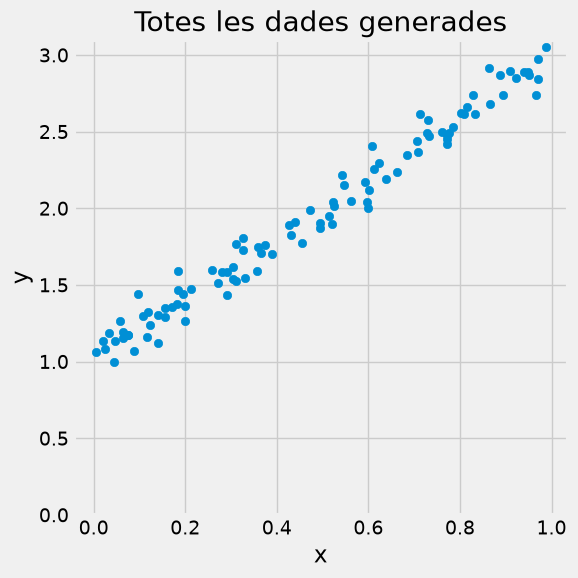

In [7]:
true_b = 1
true_w = 2
N = 100

# Data Generation
np.random.seed(42)
x = np.random.rand(N, 1)
y = true_b + true_w * x + (.1 * np.random.randn(N, 1))

def dibuixar(x, y):
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))

    ax.scatter(x, y)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_ylim([0, 3.1])
    ax.set_title('Totes les dades generades')
    fig.tight_layout()
    return fig

fig = dibuixar(x,y)

Igualment que en ocasions anteriors, convertim en tensors les dades i generem els `Dataloaders`: 

In [8]:
torch.manual_seed(13)

# Builds tensors from numpy arrays BEFORE split
x_tensor = torch.as_tensor(x).float()
y_tensor = torch.as_tensor(y).float()

# Builds dataset containing ALL data points
dataset = TensorDataset(x_tensor, y_tensor)

# Performs the split
ratio = .8
n_total = len(dataset)
n_train = int(n_total * ratio)
n_val = n_total - n_train

train_data, val_data = random_split(dataset, [n_train, n_val])

# Builds a loader of each set
train_loader = DataLoader(dataset=train_data, batch_size=16, shuffle=True)
val_loader = DataLoader(dataset=val_data, batch_size=16)

In [10]:
# Sets learning rate - this is "eta" ~ the "n" like Greek letter
lr = 0.1

torch.manual_seed(42)
# Now we can create a model and send it at once to the device
model = nn.Sequential(nn.Linear(1, 1))

# Defines a SGD optimizer to update the parameters
# (now retrieved directly from the model)
optimizer = optim.SGD(model.parameters(), lr=lr)

# Defines a MSE loss function
loss_fn = nn.MSELoss(reduction='mean')

In [11]:
print(model.state_dict())

OrderedDict({'0.weight': tensor([[0.7645]]), '0.bias': tensor([0.8300])})


In [12]:
sbs = StepByStep(model, loss_fn, optimizer)
sbs.set_loaders(train_loader, val_loader)
sbs.set_tensorboard('classy')

print(sbs.model == model)
print(sbs.model)

True
Sequential(
  (0): Linear(in_features=1, out_features=1, bias=True)
)


In [13]:
sbs.train(n_epochs=200)

In [14]:
print(model.state_dict()) # remember, model == sbs.model
print(sbs.total_epochs)

OrderedDict({'0.weight': tensor([[1.9416]]), '0.bias': tensor([1.0235])})
200


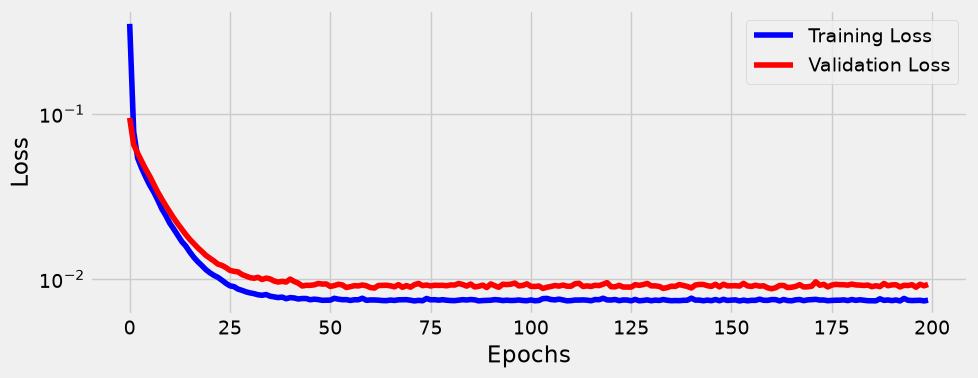

In [15]:
fig = sbs.plot_losses()

In [17]:
new_data = np.array([.5, .3, .7]).reshape(-1, 1)
predictions = sbs.predict(new_data)
print(new_data,"\n",predictions)

[[0.5]
 [0.3]
 [0.7]] 
 [[1.9942763]
 [1.605955 ]
 [2.3825974]]


In [ ]:
#sbs.save_checkpoint('model_checkpoint.pth')

In [ ]:
#new_sbs = StepByStep(model, loss_fn, optimizer)
#new_sbs.load_checkpoint('model_checkpoint.pth')
#print(model.state_dict())

## Model de Classificació

Anem a fer un model de classificació binària. Recapitularem gran part del treball desenvolupat en els anteriors exemples i veurem nous conceptes. 

In [25]:
import numpy as np

import torch
import torch.optim as optim
import torch.nn as nn
import torch.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns


### Generar dades

Per fer la classificació més interessant utilitzen `make_moons` 

In [47]:
X, y = make_moons(n_samples=100, noise=0.3, random_state=0)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=.2, random_state=13)

sc = StandardScaler()
sc.fit(X_train)

X_train = sc.transform(X_train)
X_val = sc.transform(X_val)


array([-0.33183358, -0.30276963, -1.51434476, -0.01164524, -1.73174885,
        1.38561313,  0.61427852,  0.64735912,  1.90525603, -0.78270473,
       -0.06518152,  0.28622212,  1.14421076, -1.45427846,  0.18357245,
        0.25454586, -0.14668089,  1.12556581,  1.03723625,  0.29851603])

Text(0.5, 1.0, "Conjunt d'Entrenament")

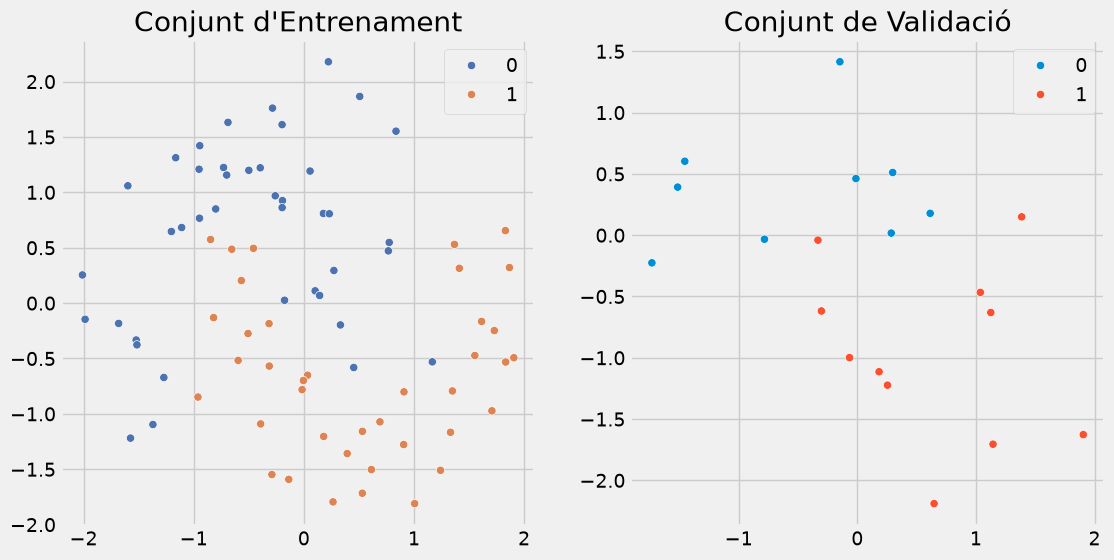

In [54]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
sns.scatterplot(x=X_val[:,0], y=X_val[:,1], hue=y_val, ax=ax[1])
sns.scatterplot(x=X_train[:,0], y=X_train[:,1], hue=y_train, palette="deep", ax=ax[0])
ax[1].set_title("Conjunt de Validació")  # Títol pel primer gràfic
ax[0].set_title("Conjunt d'Entrenament")  # Títol pel segon gràfic


In [55]:

torch.manual_seed(13)

# Builds tensors from numpy arrays
x_train_tensor = torch.as_tensor(X_train).float()
y_train_tensor = torch.as_tensor(y_train.reshape(-1, 1)).float()

x_val_tensor = torch.as_tensor(X_val).float()
y_val_tensor = torch.as_tensor(y_val.reshape(-1, 1)).float()

# Builds dataset containing ALL data points
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
val_dataset = TensorDataset(x_val_tensor, y_val_tensor)

# Builds a loader of each set
train_loader = DataLoader(dataset=train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=16)



### Crear el model 

Anem a fer un model de `regressió logística` com el conegut de machine learning. Com ja sabem, la regressió logística té com a base un model de regressió lineal dins d'una funció sigmoide. És a dir, el model ha d'ajustar una regressió lineal que donarà un número continu el qual es converteix en `probabilitats` amb una funció sigmoide. 

> Podem considerar la regressió logísitca com la segona xarxa neuronal més simple per darrere de la pròpia regressió lineal. Ja que sols és aplicar una sigmoide. 

![regressió logistica](83-1024x579.jpg)

> Les funcions sigmoides juguen un paper fonamental, ja que poden ser `funcions d'activació` dins d'una xarxa més complexa. 

In [56]:
torch.manual_seed(42)
model1 = nn.Sequential()
model1.add_module('linear', nn.Linear(2, 1))
model1.add_module('sigmoid', nn.Sigmoid())
print(model1.state_dict())

OrderedDict({'linear.weight': tensor([[0.5406, 0.5869]]), 'linear.bias': tensor([-0.1657])})


Observem que la xarxa no té pesos per a la funció sigmoide, ja que no necessita entrenar. Sols entrenem la funció lineal. 